# Braille-to-Text: Deep Learning — Model 4 (Custom CNN)
**CS363 Machine Learning — Phase 2**



## Step 0: Mount Drive & Install Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow scikit-learn matplotlib seaborn tqdm -q

import os, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Mixed precision: cuts VRAM ~50%, speeds up T4 ──
tf.keras.mixed_precision.set_global_policy('mixed_float16')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

print('✅ All libraries imported!')
print(f'📦 TensorFlow : {tf.__version__}')
print(f'🖥️  GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'🎛️  Precision  : {tf.keras.mixed_precision.global_policy().name}')


Mounted at /content/drive
✅ All libraries imported!
📦 TensorFlow : 2.20.0
🖥️  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🎛️  Precision  : mixed_float16


## Step 1: Crop Braille Cells from Angelina Dataset




In [3]:
# ── Configuration ──
DATASET_PATH = '/content/drive/MyDrive/ML Project/AngelinaDataset/books'
CROPS_DIR    = '/content/drive/MyDrive/ML Project/CNN_Crops'
CROP_SIZE    = (32, 32)   # 32×32 is sufficient for 6-dot Braille cells
                           # and keeps the T4 GPU memory budget comfortable

os.makedirs(CROPS_DIR, exist_ok=True)

print('🔍 Scanning for images and their CSV annotations...')
jpg_files = glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'), recursive=True)

paired = []
for jpg in jpg_files:
    csv = jpg.replace('.jpg', '.csv')
    if os.path.exists(csv):
        paired.append((jpg, csv))

print(f'✅ Found {len(paired)} image+annotation pairs')


🔍 Scanning for images and their CSV annotations...
✅ Found 212 image+annotation pairs


In [4]:
# ── Crop cells from every page (grayscale) ──
all_crops, all_labels = [], []
skipped = 0

for jpg_path, csv_path in tqdm(paired, desc='Cropping pages'):
    try:
        # Load as grayscale — Braille dots carry no colour information.
        # Shape per crop becomes (32, 32, 1) after expand_dims.
        img = Image.open(jpg_path).convert('L')
        W, H = img.size

        with open(csv_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split(';')
                if len(parts) != 5:
                    continue
                try:
                    l, t, r, b, label = (float(parts[0]), float(parts[1]),
                                         float(parts[2]), float(parts[3]),
                                         int(float(parts[4])))
                except ValueError:
                    continue

                x1 = max(0, int(l * W))
                y1 = max(0, int(t * H))
                x2 = min(W, int(r * W))
                y2 = min(H, int(b * H))

                if x2 <= x1 or y2 <= y1:
                    skipped += 1
                    continue

                crop = img.crop((x1, y1, x2, y2)).resize(CROP_SIZE, Image.LANCZOS)
                crop_arr = np.expand_dims(np.array(crop, dtype=np.float32) / 255.0, axis=-1)

                all_crops.append(crop_arr)
                all_labels.append(label - 1)   # shift to 0-indexed

    except Exception:
        skipped += 1
        continue

all_crops  = np.array(all_crops,  dtype=np.float32)   # (N, 32, 32, 1)
all_labels = np.array(all_labels, dtype=np.int32)

print(f'\n✅ Total crops extracted : {len(all_crops)}')
print(f'   Skipped (bad boxes)  : {skipped}')
print(f'   Unique classes       : {len(np.unique(all_labels))} (expected 63)')
print(f'   Crop array shape     : {all_crops.shape}  (grayscale = 1 channel)')
print(f'   RAM used (approx)    : {all_crops.nbytes / 1e6:.1f} MB')


Cropping pages:   0%|          | 0/212 [00:00<?, ?it/s]


✅ Total crops extracted : 66133
   Skipped (bad boxes)  : 0
   Unique classes       : 55 (expected 63)
   Crop array shape     : (66133, 32, 32, 1)  (grayscale = 1 channel)
   RAM used (approx)    : 270.9 MB


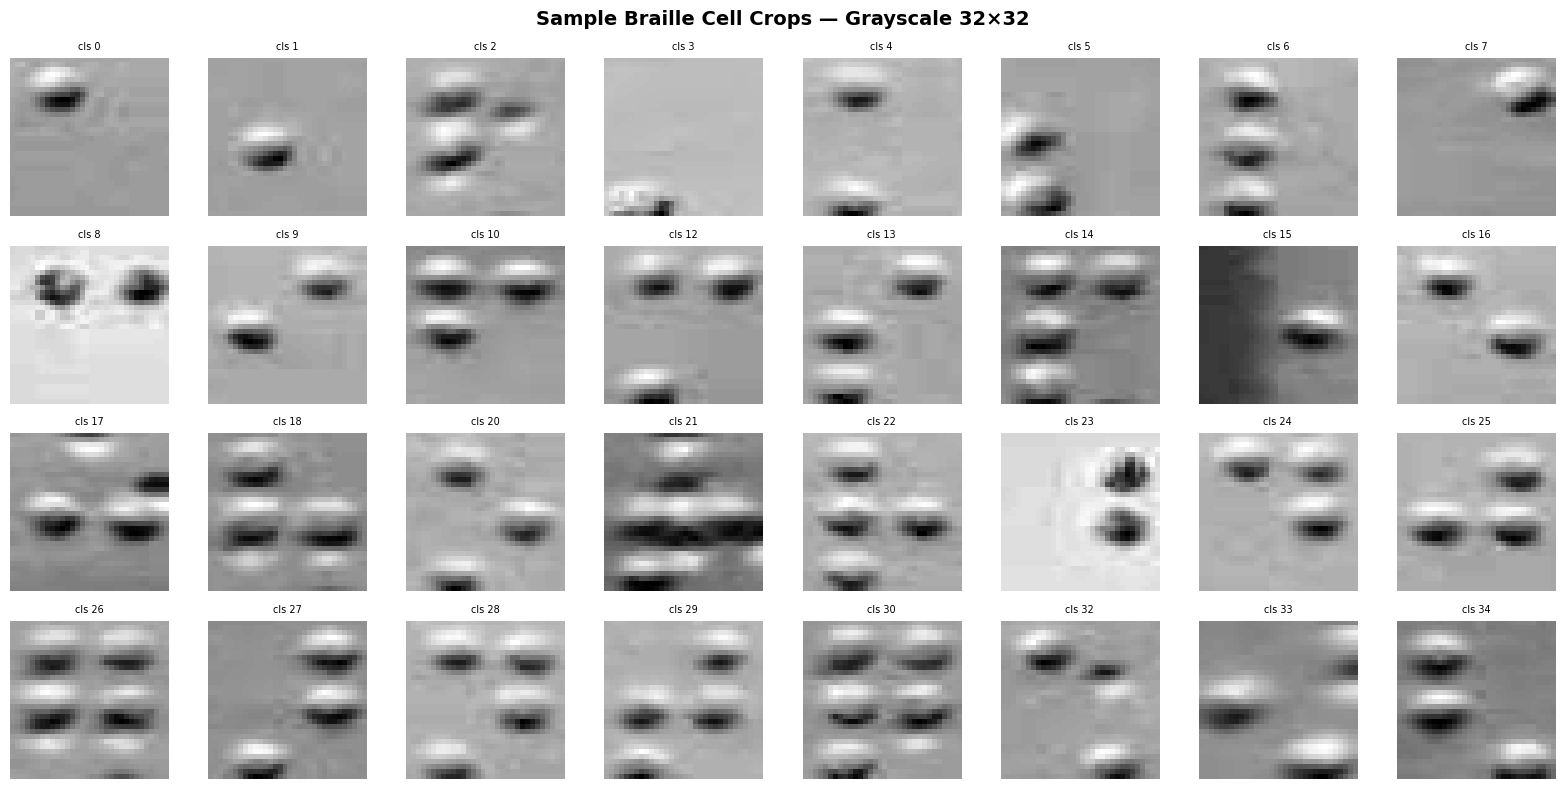

In [5]:
# ── Visualize sample crops ──
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Sample Braille Cell Crops — Grayscale 32×32', fontsize=14, fontweight='bold')

unique_labels = np.unique(all_labels)
shown = 0
for cls in unique_labels:
    if shown >= 32: break
    idx = np.where(all_labels == cls)[0][0]
    ax = axes[shown // 8][shown % 8]
    ax.imshow(all_crops[idx, :, :, 0], cmap='gray')
    ax.set_title(f'cls {cls}', fontsize=7)
    ax.axis('off')
    shown += 1

plt.tight_layout()
plt.show()


## Step 2: Train / Validation / Test Split




In [6]:
# ── Filter out classes with fewer than 3 samples (need ≥1 in each split) ──
class_counts = Counter(all_labels.tolist())
valid_classes = {cls for cls, cnt in class_counts.items() if cnt >= 3}
removed = len(class_counts) - len(valid_classes)

if removed > 0:
    mask = np.array([lbl in valid_classes for lbl in all_labels])
    all_crops  = all_crops[mask]
    all_labels = all_labels[mask]
    print(f'⚠️  Removed {removed} class(es) with < 3 samples')
else:
    print('✅ All classes have ≥ 3 samples — no filtering needed')

# ── Remap labels to contiguous 0..N-1 ──
unique_sorted = sorted(valid_classes)
label_map  = {old: new for new, old in enumerate(unique_sorted)}
all_labels = np.array([label_map[l] for l in all_labels], dtype=np.int32)
num_classes = len(unique_sorted)

# ── Step 1: carve out test set (15 %) ──
X_temp, X_test, y_temp, y_test_int = train_test_split(
    all_crops, all_labels,
    test_size=0.15, random_state=42, stratify=all_labels
)

# ── Step 2: split remainder into train (82.4 % of temp ≈ 70 % total) / val ──
X_train, X_val, y_train_int, y_val_int = train_test_split(
    X_temp, y_temp,
    test_size=0.176, random_state=42, stratify=y_temp   # 0.176 ≈ 15/85
)

# ── One-hot encode ──
y_train = tf.keras.utils.to_categorical(y_train_int, num_classes)
y_val   = tf.keras.utils.to_categorical(y_val_int,   num_classes)
y_test  = tf.keras.utils.to_categorical(y_test_int,  num_classes)

total = len(all_crops)
print(f'\n📊 Classes after filtering : {num_classes}')
print(f'   Train : {len(X_train):6,}  ({len(X_train)/total*100:.1f} %)')
print(f'   Val   : {len(X_val):6,}  ({len(X_val)/total*100:.1f} %)')
print(f'   Test  : {len(X_test):6,}  ({len(X_test)/total*100:.1f} %)')


⚠️  Removed 3 class(es) with < 3 samples

📊 Classes after filtering : 52
   Train : 46,316  (70.0 %)
   Val   :  9,893  (15.0 %)
   Test  :  9,920  (15.0 %)


## Step 2b: Class-Weight Balancing



✅ Class weights computed for 52 classes.
   Min weight : 0.207  (most common class)
   Max weight : 296.897  (rarest class)
   Ratio      : 1435.7×


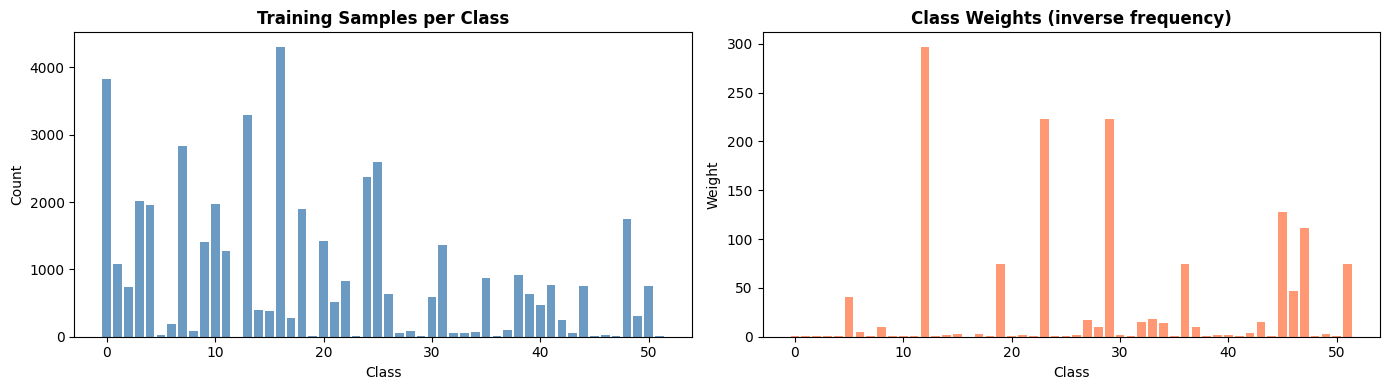

In [7]:
# ── Compute class weights from training labels only ──
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train_int
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print(f'✅ Class weights computed for {num_classes} classes.')
print(f'   Min weight : {min(class_weights_arr):.3f}  (most common class)')
print(f'   Max weight : {max(class_weights_arr):.3f}  (rarest class)')
print(f'   Ratio      : {max(class_weights_arr)/min(class_weights_arr):.1f}×')

# ── Class distribution bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts_train = [int((y_train_int == c).sum()) for c in range(num_classes)]
axes[0].bar(range(num_classes), counts_train, color='steelblue', alpha=0.8)
axes[0].set_title('Training Samples per Class', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[1].bar(range(num_classes), class_weights_arr, color='coral', alpha=0.8)
axes[1].set_title('Class Weights (inverse frequency)', fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Weight')
plt.tight_layout(); plt.show()


## Step 3: Data Augmentation

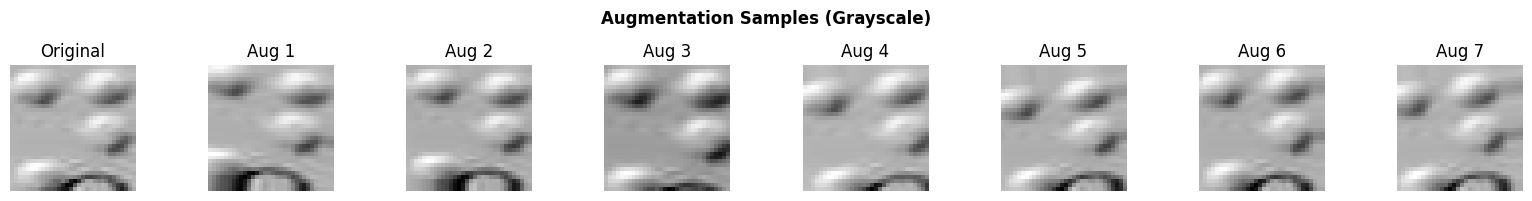

✅ Augmentation configured.


In [8]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.05,
    horizontal_flip=False,   # Braille is direction-sensitive — never flip
    fill_mode='nearest'
)
datagen.fit(X_train)

# Show augmented samples
sample = X_train[0:1]
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0, :, :, 0], cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
for i, batch in enumerate(datagen.flow(sample, batch_size=1)):
    axes[i+1].imshow(batch[0, :, :, 0], cmap='gray')
    axes[i+1].set_title(f'Aug {i+1}'); axes[i+1].axis('off')
    if i == 6: break
plt.suptitle('Augmentation Samples (Grayscale)', fontweight='bold')
plt.tight_layout(); plt.show()
print('✅ Augmentation configured.')


## Step 4: Build the Custom CNN


In [9]:
def build_custom_cnn(input_shape=(32, 32, 1), num_classes=63):
    model = models.Sequential(name='BrailleCNN_v2')

    # ── Block 1 — 32 filters ──
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2 — 64 filters ──
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3 — 128 filters (now 2 conv layers, matching Blocks 1 & 2) ──
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same'))   # ← added
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    # ── Classifier head ──
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)   # L2 on Dense 1
    ))
    model.add(layers.Dropout(0.40))
    model.add(layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)   # ← L2 on Dense 2 (fix)
    ))
    model.add(layers.Dropout(0.30))
    # dtype='float32' is required — mixed precision must not affect the output layer
    model.add(layers.Dense(num_classes, activation='softmax', dtype='float32'))

    return model

cnn_model = build_custom_cnn(input_shape=(32, 32, 1), num_classes=num_classes)
cnn_model.summary()
print(f'\n📊 Total parameters : {cnn_model.count_params():,}')


Model: "BrailleCNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 360,852 (1.38 MB)

 Trainable params: 359,956 (1.37 MB)

 Non-trainable params: 896 (3.50 KB)


📊 Total parameters : 360,852


## Step 5: Compile & Train

In [10]:
SAVE_PATH = '/content/drive/MyDrive/ML Project/CNN_Runs'
os.makedirs(SAVE_PATH, exist_ok=True)

# Lower initial LR (5e-4 instead of 1e-3) — safer with BatchNorm + mixed precision
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list = [
    callbacks.ModelCheckpoint(
        f'{SAVE_PATH}/best_cnn_braille.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    )
]

BATCH_SIZE = 64   # T4-safe; 64 × 32×32×1 float16 ≈ 4 MB per batch
EPOCHS     = 80

# math.ceil ensures NO samples are silently dropped each epoch
steps_per_epoch = math.ceil(len(X_train) / BATCH_SIZE)

print('🚀 Starting Custom CNN Training...')
print(f'   Batch size        : {BATCH_SIZE}')
print(f'   Max epochs        : {EPOCHS}')
print(f'   Steps per epoch   : {steps_per_epoch} (ceil, no samples dropped)')
print(f'   Train crops       : {len(X_train)}')
print(f'   Val   crops       : {len(X_val)}')
print(f'   Test  crops       : {len(X_test)}')
print(f'   Class weights     : enabled ({num_classes} classes)')
print('-' * 55)

history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    # ── validation set is now a clean held-out set, separate from test ──
    validation_data=(X_val, y_val),
    # ── class weights balance minority characters ──
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

print('\n✅ Training complete!')


🚀 Starting Custom CNN Training...
   Batch size        : 64
   Max epochs        : 80
   Steps per epoch   : 724 (ceil, no samples dropped)
   Train crops       : 46316
   Val   crops       : 9893
   Test  crops       : 9920
   Class weights     : enabled (52 classes)
-------------------------------------------------------
Epoch 1/80
722/724 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0196 - loss: 4.0289
Epoch 1: val_accuracy improved from None to 0.00657, saving model to /content/drive/MyDrive/ML Project/CNN_Runs/best_cnn_braille.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML Project/CNN_Runs/best_cnn_braille.keras
724/724 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - accuracy: 0.0187 - loss: 4.0373 - val_accuracy: 0.0066 - val_loss: 3.9251 - learning_rate: 5.0000e-04
Epoch 2/80
723/724 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0184 - loss: 4.0860
Epoch 2: val_accuracy improved from 0.00657 to 0.03558, saving model to /content/drive/MyDrive/ML Project/CNN_Runs/bes

## Step 6: Training Curves

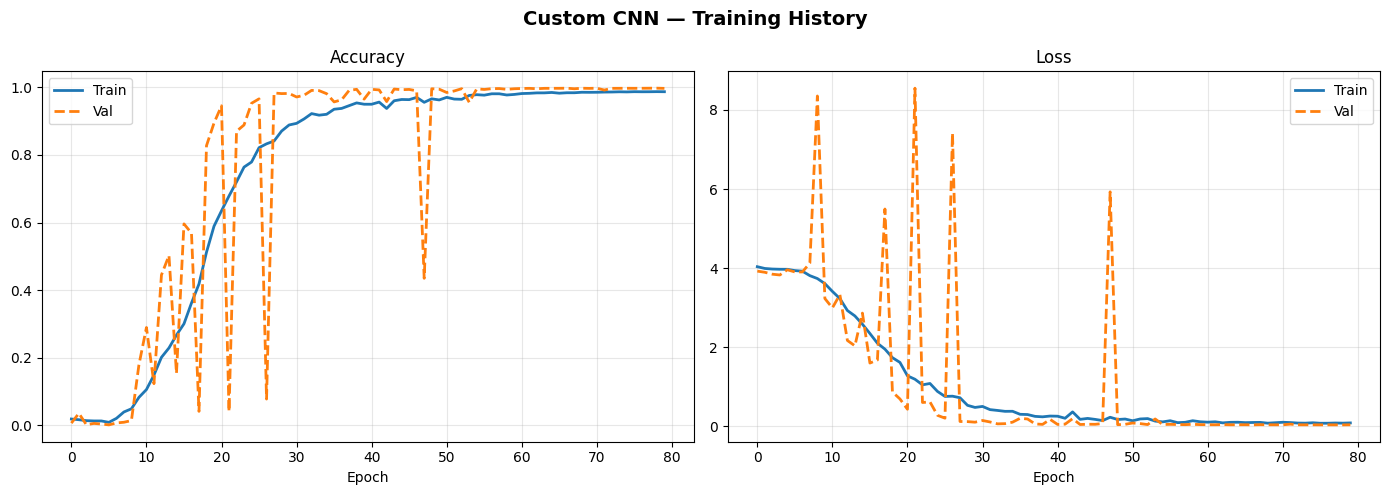

✅ Curves saved to Drive.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curves saved to Drive.')


## Step 7: Evaluation & Metrics



In [12]:
# Load best checkpoint weights
cnn_model.load_weights(f'{SAVE_PATH}/best_cnn_braille.keras')

# Predict on the clean test set
y_pred_prob = cnn_model.predict(X_test, verbose=0)
y_pred_int  = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred_int, average='weighted'
)

print('=' * 55)
print('  🏆 CUSTOM CNN — FINAL EVALUATION REPORT')
print('=' * 55)
print(f'  Accuracy            : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (weighted): {precision:.4f}')
print(f'  Recall    (weighted): {recall:.4f}')
print(f'  F1-Score  (weighted): {f1:.4f}')
print('=' * 55)
print()
print('📋 Per-Class Classification Report:')
print(classification_report(y_test_int, y_pred_int))


  🏆 CUSTOM CNN — FINAL EVALUATION REPORT
  Accuracy            : 0.9972  (99.72%)
  Precision (weighted): 0.9973
  Recall    (weighted): 0.9972
  F1-Score  (weighted): 0.9972

📋 Per-Class Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       820
           1       1.00      1.00      1.00       231
           2       0.98      1.00      0.99       159
           3       1.00      1.00      1.00       433
           4       1.00      1.00      1.00       418
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00        41
           7       1.00      1.00      1.00       607
           8       1.00      1.00      1.00        19
           9       0.99      1.00      1.00       300
          10       1.00      1.00      1.00       422
          11       1.00      1.00      1.00       274
          12       1.00      1.00      1.00         1
          13       1.00      1.0

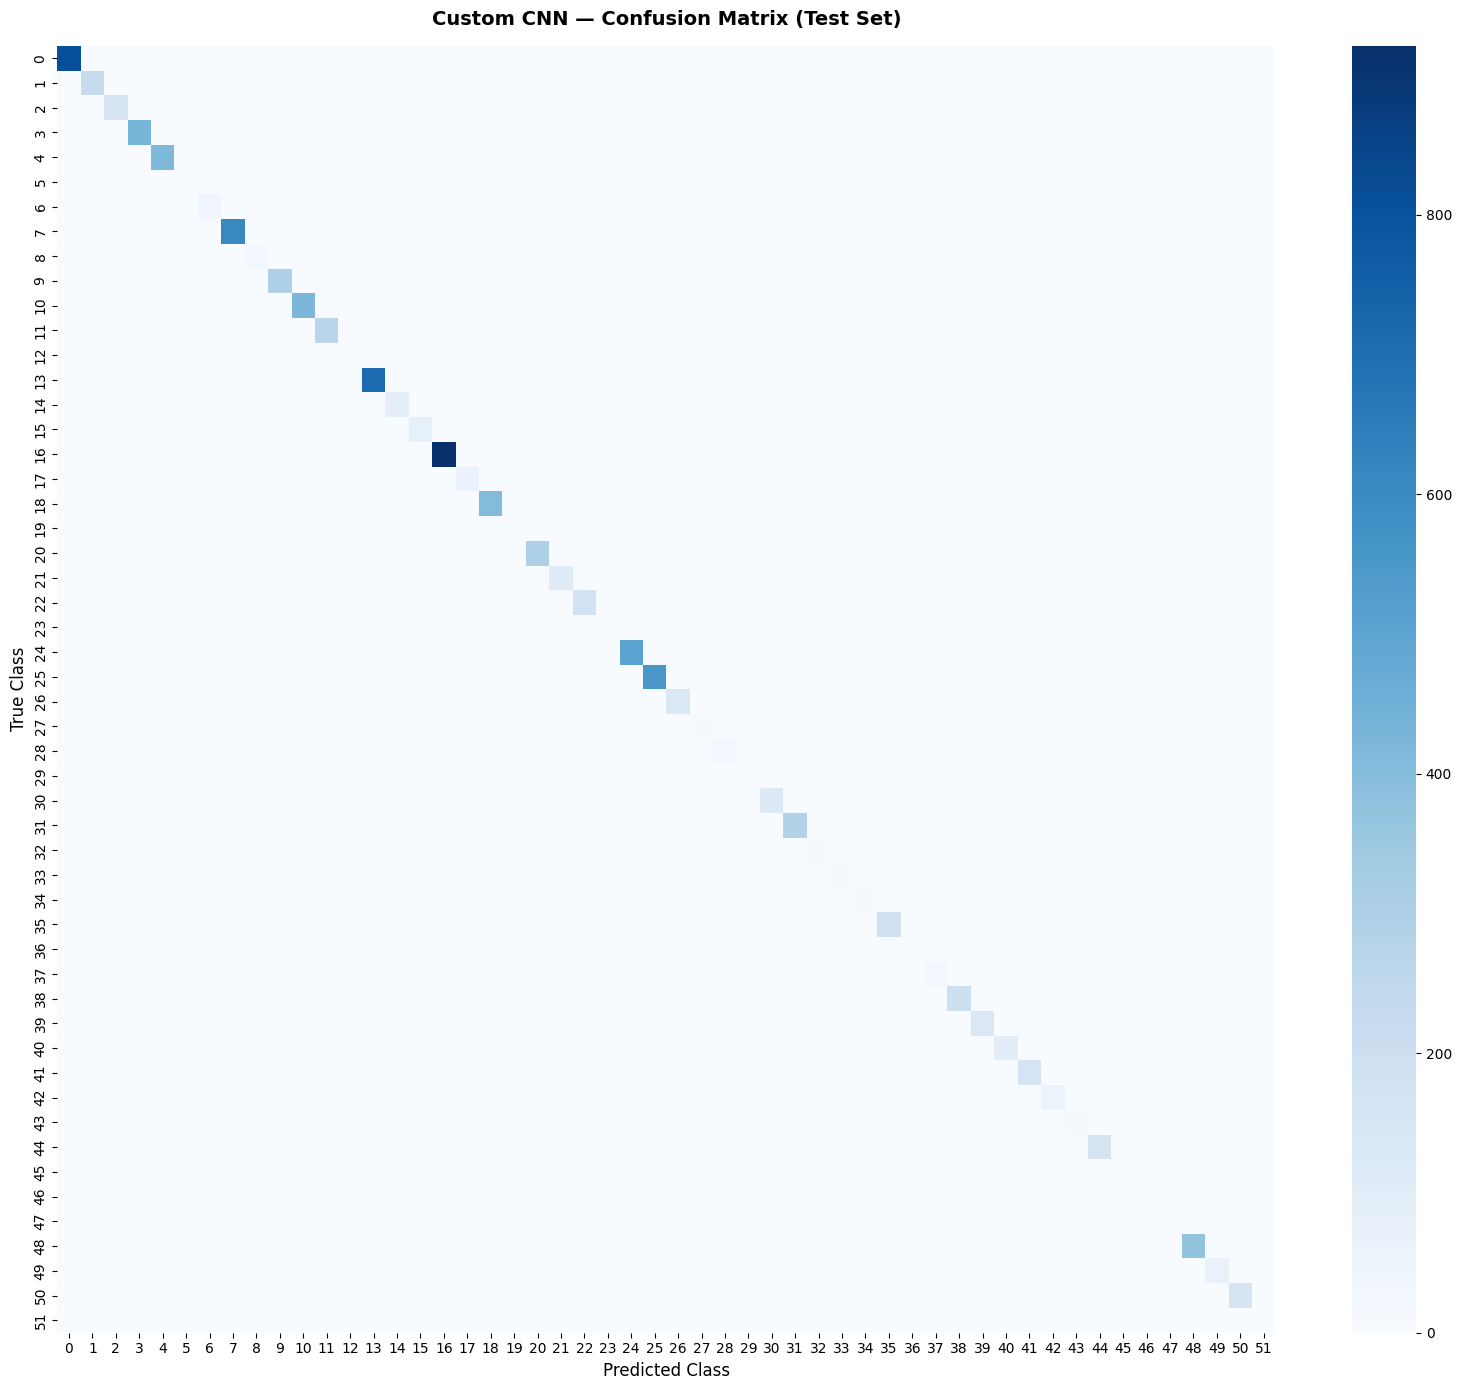

✅ Confusion matrix saved to Drive.


In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred_int)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
            xticklabels=range(num_classes),
            yticklabels=range(num_classes))
ax.set_title('Custom CNN — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved to Drive.')


## Step 8: Visual Prediction Samples

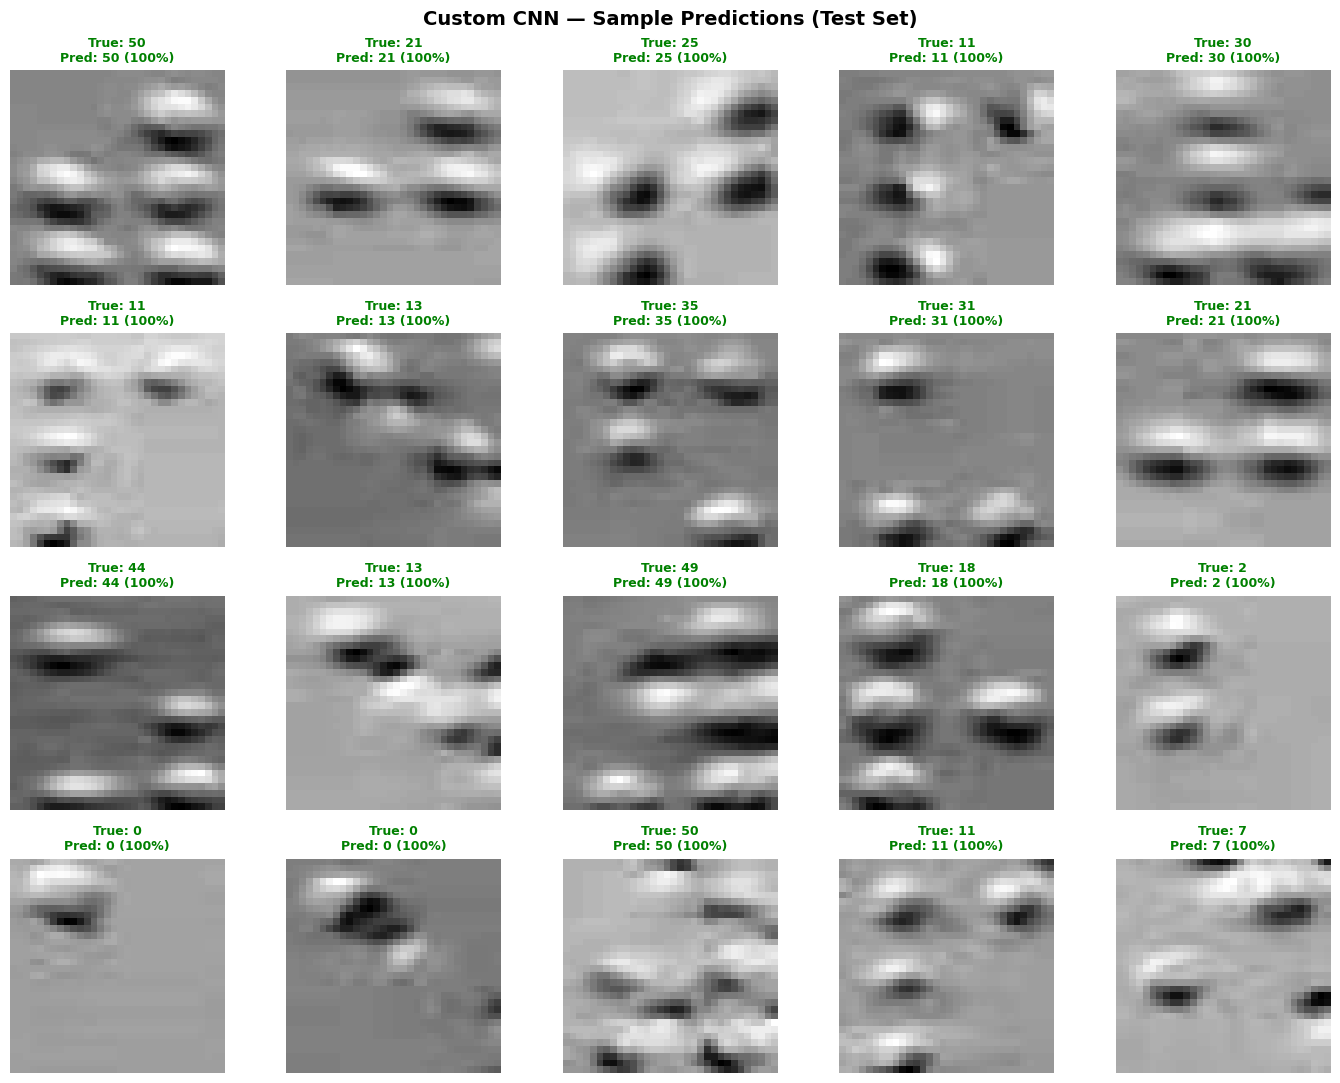

✅ Prediction samples saved to Drive.


In [14]:
np.random.seed(42)
indices = np.random.choice(len(X_test), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Custom CNN — Sample Predictions (Test Set)', fontsize=14, fontweight='bold')

for i, idx in enumerate(indices):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    true_lbl = y_test_int[idx]
    pred_lbl = y_pred_int[idx]
    conf     = y_pred_prob[idx][pred_lbl]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.0%})',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/cnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction samples saved to Drive.')


## Step 9: Final Summary

In [15]:
best_val_acc   = max(history.history['val_accuracy'])
epochs_trained = len(history.history['accuracy'])

print('\n' + '='*62)
print('  📊 CUSTOM CNN v2 — FINAL SUMMARY')
print('='*62)
print(f'  Architecture       : 3-block CNN + GAP + 2 Dense layers')
print(f'  Input              : 32×32 Grayscale crops (Angelina Dataset)')
print(f'  Total Parameters   : {cnn_model.count_params():,}')
print(f'  Precision policy   : mixed_float16 (T4-optimised)')
print(f'  Split              : 70 % train / 15 % val / 15 % test')
print(f'  Class weighting    : enabled (balanced inverse-frequency)')
print(f'  Epochs Trained     : {epochs_trained} (EarlyStopping applied)')
print(f'  Best Val Accuracy  : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'  Test Accuracy      : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Test F1-Score      : {f1:.4f}')
print('='*62)
print(f'\n✅ Model saved to: {SAVE_PATH}/best_cnn_braille.keras')



  📊 CUSTOM CNN v2 — FINAL SUMMARY
  Architecture       : 3-block CNN + GAP + 2 Dense layers
  Input              : 32×32 Grayscale crops (Angelina Dataset)
  Total Parameters   : 360,852
  Precision policy   : mixed_float16 (T4-optimised)
  Split              : 70 % train / 15 % val / 15 % test
  Class weighting    : enabled (balanced inverse-frequency)
  Epochs Trained     : 80 (EarlyStopping applied)
  Best Val Accuracy  : 0.9975 (99.75%)
  Test Accuracy      : 0.9972 (99.72%)
  Test F1-Score      : 0.9972

✅ Model saved to: /content/drive/MyDrive/ML Project/CNN_Runs/best_cnn_braille.keras
